In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings

In [68]:
oil = pd.read_csv("http://137.23.24.234/datasets//store-sales-forecasting/oil.csv")
sample_submission = pd.read_csv("http://137.23.24.234/datasets/store-sales-forecasting/sample_submission.csv")
df = pd.read_csv("http://137.23.24.234/datasets/store-sales-forecasting/train.csv")
holidays = pd.read_csv("http://137.23.24.234/datasets/store-sales-forecasting/holidays_events.csv")
# 

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [70]:
df["family"].unique()

<StringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',
            'LAWN AND GARDEN',                   'LINGERIE',
           'LIQUOR,WINE,BEER',                  'MAGAZINES',
                      'MEATS',              'PERSONAL CARE',
               'PET SUPPLIES',    'PLAYERS AND ELECTRONICS',
                    'POULTRY',             'PREPARED FOODS',
                    'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
          

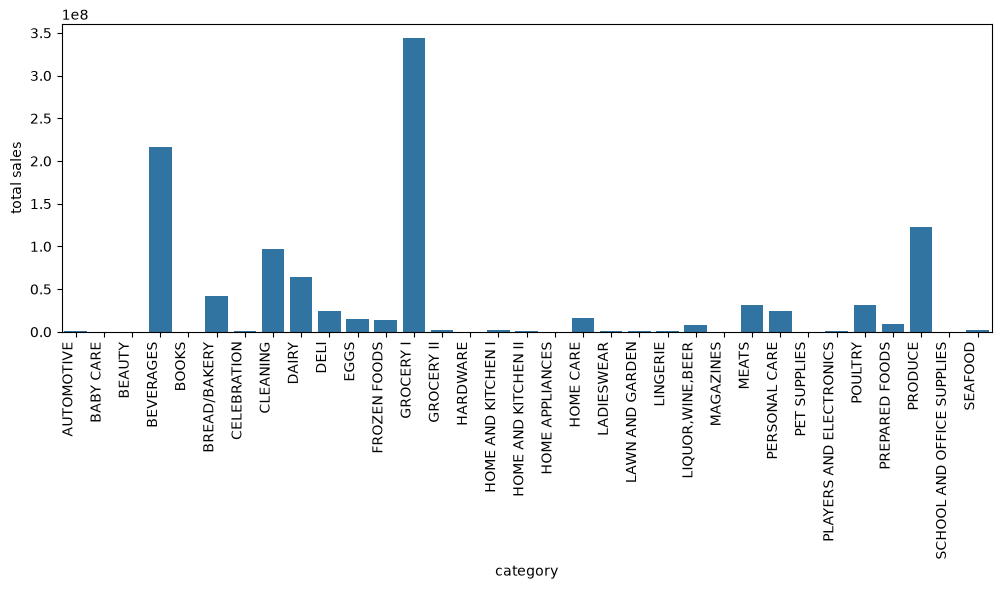

In [71]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.barplot(
    data=df,
    x="family",
    y="sales",
    estimator="sum",
    errorbar=None
)

plt.xlabel("category")
plt.ylabel("total sales")
plt.xticks(rotation=90, ha="right")

plt.show()

In [72]:
category = "GROCERY I"
store_number = 46

df["date"] = pd.to_datetime(df["date"])

store_cat_sales = df[(df["family"] == category) & (df["store_nbr"] == store_number)]

print(store_cat_sales)

              id       date  store_nbr     family    sales  onpromotion
1332        1332 2013-01-01         46  GROCERY I      0.0            0
3114        3114 2013-01-02         46  GROCERY I  10892.0            0
4896        4896 2013-01-03         46  GROCERY I   6493.0            0
6678        6678 2013-01-04         46  GROCERY I   6499.0            0
8460        8460 2013-01-05         46  GROCERY I  10827.0            0
...          ...        ...        ...        ...      ...          ...
2993310  2993310 2017-08-11         46  GROCERY I   9934.0           41
2995092  2995092 2017-08-12         46  GROCERY I   9218.0           40
2996874  2996874 2017-08-13         46  GROCERY I  10557.0           40
2998656  2998656 2017-08-14         46  GROCERY I   7570.0           39
3000438  3000438 2017-08-15         46  GROCERY I   7222.0           37

[1684 rows x 6 columns]


In [73]:
series = store_cat_sales.set_index("date").sort_index()[["sales", "onpromotion"]]

series = series.asfreq('D').interpolate('time')

print(series)

              sales  onpromotion
date                            
2013-01-01      0.0          0.0
2013-01-02  10892.0          0.0
2013-01-03   6493.0          0.0
2013-01-04   6499.0          0.0
2013-01-05  10827.0          0.0
...             ...          ...
2017-08-11   9934.0         41.0
2017-08-12   9218.0         40.0
2017-08-13  10557.0         40.0
2017-08-14   7570.0         39.0
2017-08-15   7222.0         37.0

[1688 rows x 2 columns]


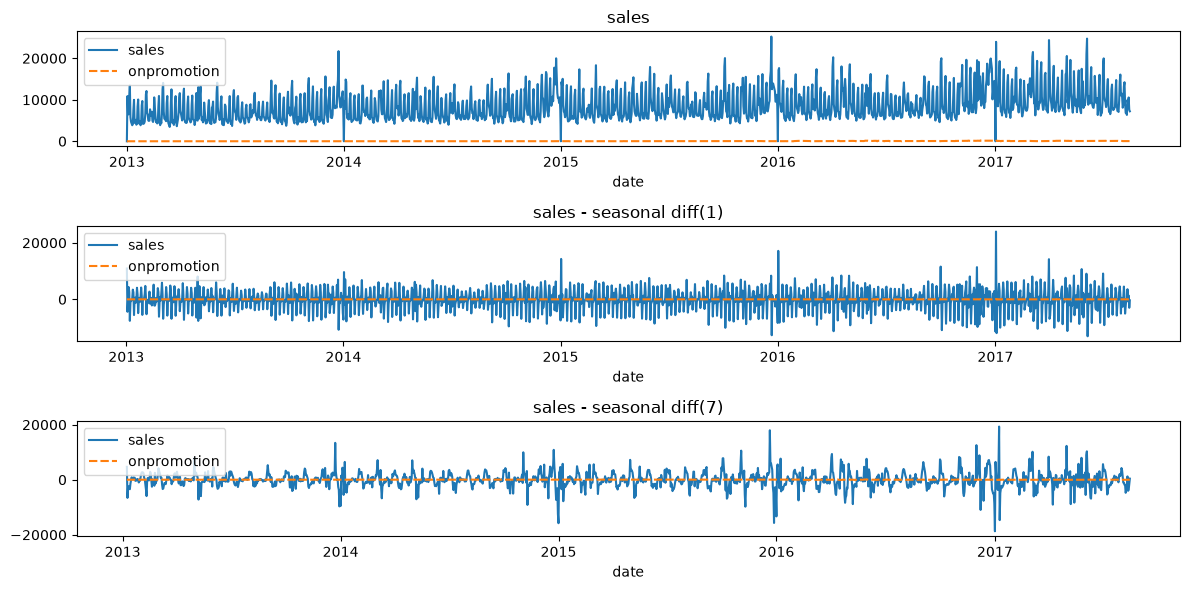

In [74]:
# plot the total sales and difference
fig, ax = plt.subplots(3, 1, figsize=(12, 6))
sns.lineplot(data=series, ax=ax[0])
sns.lineplot(data=series.diff(1), ax=ax[1])
sns.lineplot(data=series.diff(7), ax=ax[2])

ax[0].set_title("sales")
ax[1].set_title("sales - seasonal diff(1)")
ax[2].set_title("sales - seasonal diff(7)")

plt.tight_layout()
plt.show()

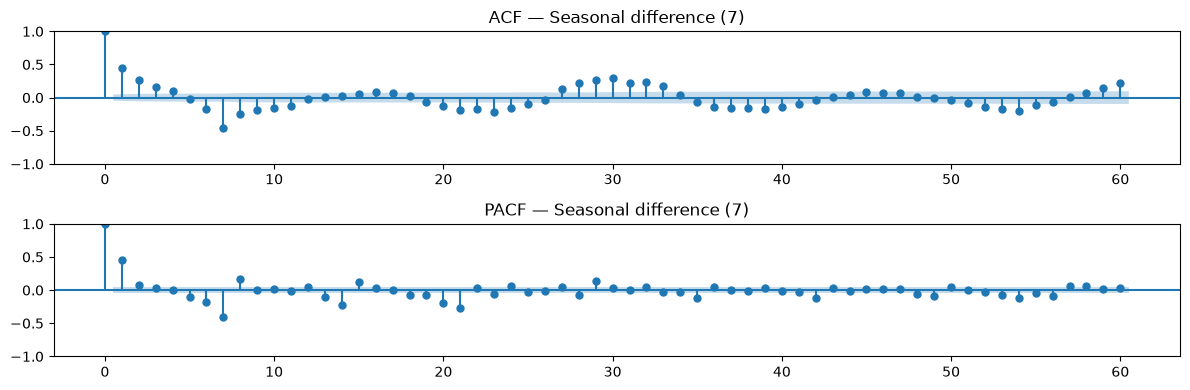

In [75]:
# ACF & PACF ANALYSIS

diffed = series["sales"].diff(7).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
plot_acf(diffed,  lags=60, ax=axes[0], title="ACF — Seasonal difference (7)")
plot_pacf(diffed, lags=60, ax=axes[1], title="PACF — Seasonal difference (7)", method="ywm")
plt.tight_layout()
plt.show()

In [76]:
# @title
# ADF test reports

def adf_report(x, label=""):
    results = adfuller(x.dropna(), autolag="AIC")
    print(f"--- ADF test: {label} ---")
    print(f"ADF statistic: {results[0]:.4f}")
    print(f"p-value: {results[1]:.4f}")
    for k, v in results[4].items():
        print(f"  critical value ({k}): {v:.4f}")
    if results[1] < 0.05:
        print("=> Reject H0: series looks stationary\n")
    else:
        print("=> Fail to reject H0: series looks non-stationary\n")

adf_report(series["sales"], "total_sales")

adf_report(series["sales"].diff(7), "total_sales first difference")

--- ADF test: total_sales ---
ADF statistic: -4.3706
p-value: 0.0003
  critical value (1%): -3.4343
  critical value (5%): -2.8633
  critical value (10%): -2.5677
=> Reject H0: series looks stationary

--- ADF test: total_sales first difference ---
ADF statistic: -13.5941
p-value: 0.0000
  critical value (1%): -3.4343
  critical value (5%): -2.8633
  critical value (10%): -2.5677
=> Reject H0: series looks stationary



<bound method Series.info of date
2013-01-01     0.0
2013-01-02     0.0
2013-01-03     0.0
2013-01-04     0.0
2013-01-05     0.0
              ... 
2017-08-11    41.0
2017-08-12    40.0
2017-08-13    40.0
2017-08-14    39.0
2017-08-15    37.0
Freq: D, Name: onpromotion, Length: 1688, dtype: float64>


<Axes: title={'center': 'onpromotion'}, xlabel='date'>

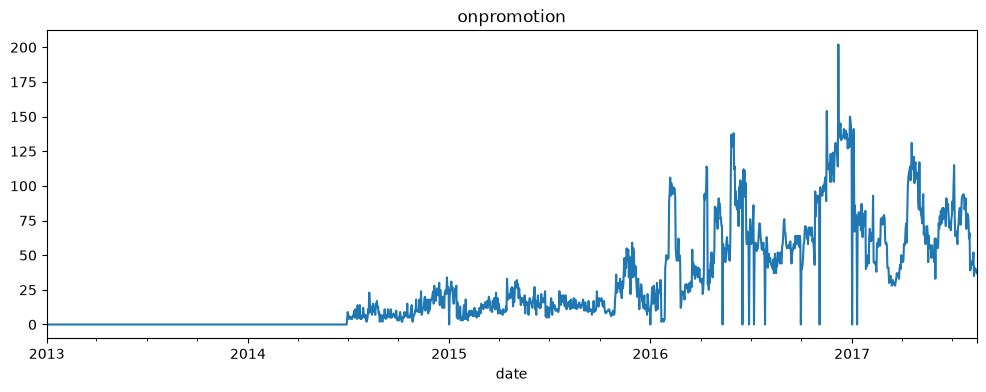

In [77]:
print(series["onpromotion"].info)

series["onpromotion"].plot(figsize=(12, 4), title="onpromotion")

<bound method Series.info of date
2013-01-01     0.0
2013-01-02     0.0
2013-01-03     0.0
2013-01-04     0.0
2013-01-05     0.0
              ... 
2017-08-11    41.0
2017-08-12    40.0
2017-08-13    40.0
2017-08-14    39.0
2017-08-15    37.0
Freq: D, Name: onpromotion, Length: 1688, dtype: float64>


<Axes: title={'center': 'onpromotion'}, xlabel='date'>

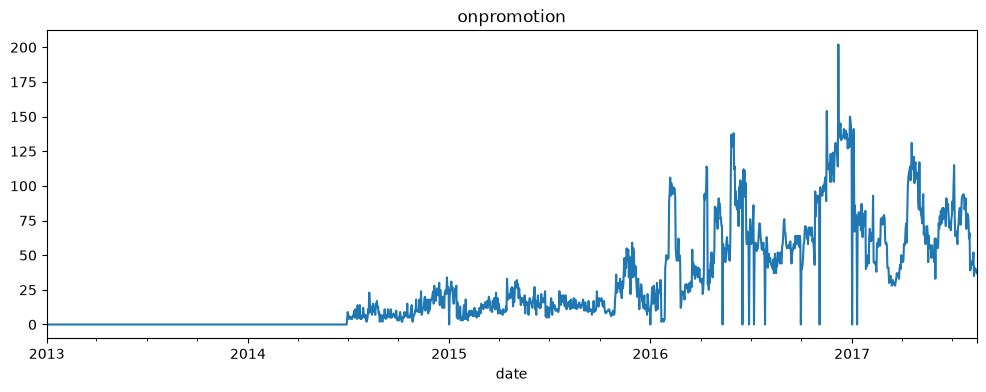

In [78]:
print(series["onpromotion"].info)

series["onpromotion"].plot(figsize=(12, 4), title="onpromotion")


In [79]:
# SARIMA model 
test_size = 60

# missing value handling
series[series["sales"] == 0] = np.nan 
series.loc[series["onpromotion"].isna(), "onpromotion"] = 0

# log transformation
series["log_sales"] = np.log(series["sales"] + 1)

# SPLIT TRAIN AND TEST SETS
train = series.iloc[: -test_size].copy()
test = series.iloc[-test_size:].copy()

# SARIMAX model with exogenous variable (onpromotion)
model = SARIMAX(
train["log_sales"],
order=(1, 1, 1),
seasonal_order=(0, 1, 1, 7),
enforce_stationarity=False,
enforce_invertibility=False,
exog=train["onpromotion"]
)

results = model.fit()

print(results.summary())

# Forecast and invert log transformation back to original scale
log_forecast = results.forecast(steps=test_size, exog=test["onpromotion"])
forecast = np.expm1(log_forecast)  # Inverts np.log1p



                                     SARIMAX Results                                     
Dep. Variable:                         log_sales   No. Observations:                 1628
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood                 592.420
Date:                           Wed, 05 Aug 2026   AIC                          -1174.840
Time:                                   13:51:51   BIC                          -1147.917
Sample:                               01-01-2013   HQIC                         -1164.846
                                    - 06-16-2017                                         
Covariance Type:                             opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
onpromotion     0.0011      0.000      3.161      0.002       0.000       0.002
ar.L1           0.6098      0.017     36

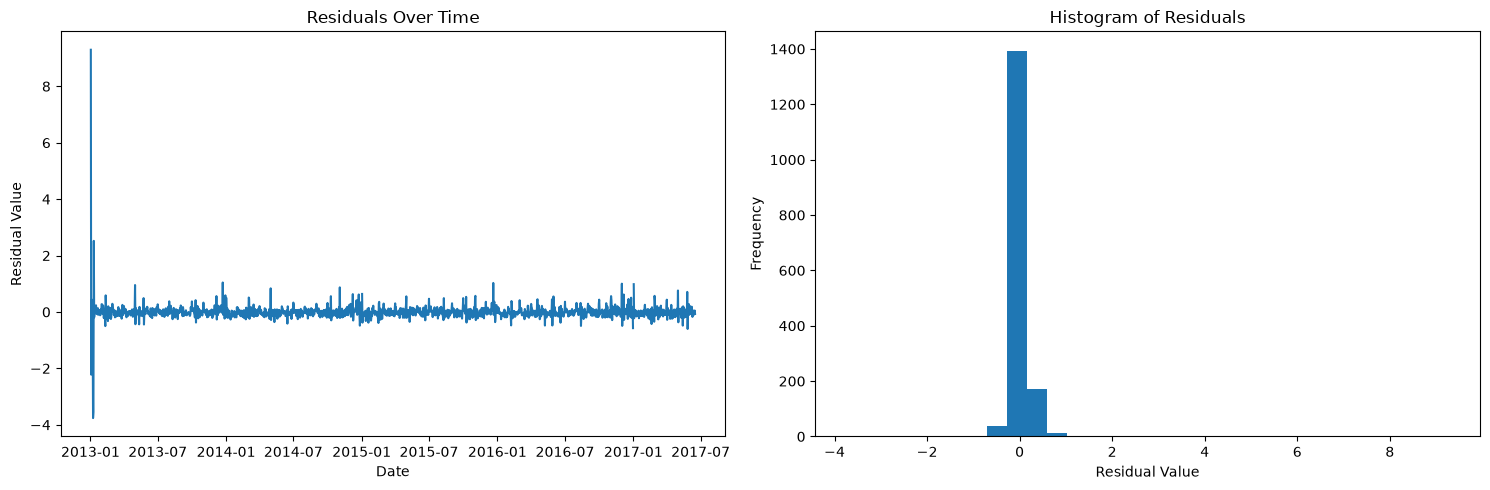

In [80]:
# Get the residuals from the model results
residuals = pd.DataFrame(results.resid)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot the residuals over time
axes[0].plot(residuals)
axes[0].set_title('Residuals Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual Value')

# Plot a histogram of the residuals
axes[1].hist(residuals, bins=30)
axes[1].set_title('Histogram of Residuals')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [81]:
# --- 1. Generate Forecasts for the test set---
# exog features ('onpromotion') for the test horizon
test_exog = test[["onpromotion"]]

forecast_object = results.get_forecast(steps=len(test), exog=test_exog)
log_forecast = forecast_object.predicted_mean
confidence_int_log = forecast_object.conf_int()

# --- 2. Invert Log Transformation Back to Original Scale ---
# Using np.expm1 to match np.log1p (expm1(x) = exp(x) - 1)
y_pred = np.expm1(log_forecast)

# Convert prediction interval back to original scale
lower_bound = np.expm1(confidence_int_log.iloc[:, 0])
upper_bound = np.expm1(confidence_int_log.iloc[:, 1])

# Clip bounds and predictions at zero to prevent impossible negative sales
y_pred = np.maximum(y_pred, 0)
lower_bound = np.maximum(lower_bound, 0)

# --- 3. Compute Accuracy Metrics on Real Sales Scale ---
y_true = test["sales"]

mae = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)

print(f"==========================================")
print(f" Model Evaluation: SARIMAX(1,1,1)(0,1,1,7)")
print(f" Forecast Horizon: {len(test)} days")
print(f"==========================================")
print(f" MAE  : {mae:.2f}")
print(f" RMSE : {rmse:.2f}")
print(f"==========================================")

# Run this snippet to compute relative performance
mean_sales = test["sales"].mean()
mape = np.mean(np.abs((test["sales"] - y_pred) / test["sales"])) * 100
nrmse = (rmse / mean_sales) * 100

print(f"Average Daily Sales: {mean_sales:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Normalized RMSE (NRMSE): {nrmse:.2f}%")

 Model Evaluation: SARIMAX(1,1,1)(0,1,1,7)
 Forecast Horizon: 60 days
 MAE  : 1908.15
 RMSE : 2334.27
Average Daily Sales: 10081.98
Mean Absolute Percentage Error (MAPE): 19.81%
Normalized RMSE (NRMSE): 23.15%


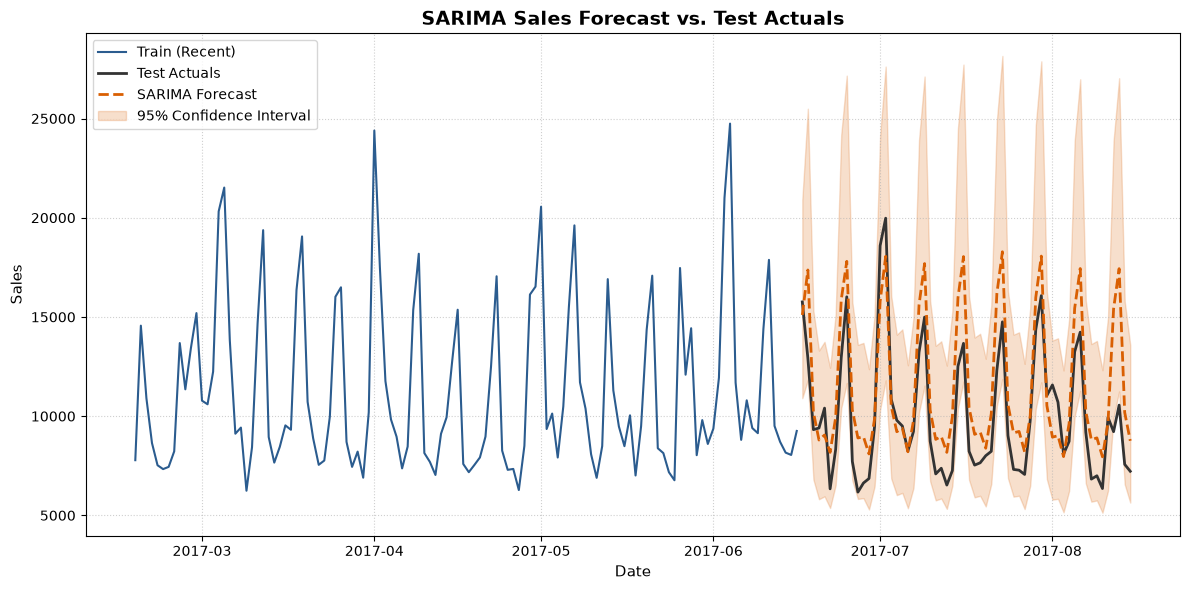

In [82]:
# forecast visualization
# --- 1. Get Forecast and Confidence Intervals on Log Scale ---
forecast_object = results.get_forecast(steps=test_size, exog=test["onpromotion"])
log_forecast = forecast_object.predicted_mean
confidence_int_log = forecast_object.conf_int()

# --- 2. Invert Log Transformation Back to Original Scale ---
# Using np.expm1 to match np.log1p (expm1(x) = exp(x) - 1)
forecast_actual_scale = np.expm1(log_forecast)

confidence_int_actual = np.expm1(confidence_int_log)
lower_bound = confidence_int_actual.iloc[:, 0]
upper_bound = confidence_int_actual.iloc[:, 1]

# Ensure no negative sales values in bounds after inversion
lower_bound = np.maximum(lower_bound, 0)
forecast_actual_scale = np.maximum(forecast_actual_scale, 0)

# --- 3. Compute Metrics on Original Sales Scale ---
y_true = test["sales"]
y_pred = forecast_actual_scale

# --- 4. Plot Results ---
plt.figure(figsize=(12, 6))

# Plot recent training data (e.g., last 180 days for context)
plt.plot(
    train.index[-120:],
    train["sales"].tail(120),
    label="Train (Recent)",
    color="#2b5c8f",
)

# Plot actual test sales
plt.plot(test.index, y_true, label="Test Actuals", color="#333333", linewidth=2)

# Plot point forecast
plt.plot(
    test.index,
    y_pred,
    label="SARIMA Forecast",
    color="#d95f02",
    linewidth=2,
    linestyle="--",
)

# Plot confidence interval (shaded region)
plt.fill_between(
    test.index,
    lower_bound,
    upper_bound,
    color="#d95f02",
    alpha=0.2,
    label="95% Confidence Interval",
)

plt.title("SARIMA Sales Forecast vs. Test Actuals", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=11)
plt.ylabel("Sales", fontsize=11)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()